# Importación de librerias

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
from scipy.stats import t as t_dist
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Fijamos una semilla para reproducibilidad
SEED = 1
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hiperparámetros óptimos (seleccionados por grid search) ───────────────
L_RET  = 40;  UNITS_RET  = 32;  DROPOUT_RET  = 0.2  # LSTM retornos
L_VOL  = 60;  UNITS_VOL  = 32;  DROPOUT_VOL  = 0.3  # LSTM volatilidad
N_RUNS = 20

# ── Referencias modelos clásicos ──────────────────────────────────────────
ARIMA_REF = {"MAE": 3.1912, "RMSE": 4.3229, "MAPE": 0.5912}
GARCH_REF = {"MSE": 1.409003, "QLIKE": 0.559411}
IC_GARCH  = {"Cobertura": 97.2, "Anchura": 4.00}
NU_T      = 5.82   # grados de libertad t-Student del GARCH


# Carga de datos y split temporal

In [20]:

print("="*65)
print("  CARGA DE DATOS")
print("="*65)

df = yf.download("SPY", start="2010-01-01", end="2024-12-31",
                 interval="1d", auto_adjust=False)
df = df[["Close"]]
df["Change %"]   = df["Close"].pct_change() * 100
df["r2"]         = df["Change %"] ** 2
df["log_r2"] = np.log(df["r2"] + 2)
df = df.dropna()

fecha_corte = df.index.max() - pd.DateOffset(years=1)
df_train    = df[df.index <  fecha_corte].copy()
df_test     = df[df.index >= fecha_corte].copy()

print(f"Train: {len(df_train)} obs.  "
      f"({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Test : {len(df_test)}  obs.  "
      f"({df_test.index[0].date()} → {df_test.index[-1].date()})")

# Datos fijos para métricas de precio
precio_real_arr  = np.array(df_test["Close"].values).ravel()
precio_prev_arr  = np.concatenate([
    df_train["Close"].iloc[[-1]].values.ravel(),
    precio_real_arr[:-1]
])
real_ret_arr     = np.array(df_test["Change %"].values).ravel()
r2_real_arr      = np.array(df_test["r2"].values).ravel()
fechas_test      = df_test.index


[*********************100%***********************]  1 of 1 completed

  CARGA DE DATOS
Train: 3521 obs.  (2010-01-05 → 2023-12-29)
Test : 251  obs.  (2024-01-02 → 2024-12-30)


## Funciones generales

In [ ]:
def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


def rolling_forecast_1step(model, arr_full, train_size, lookback, n_features):
    historia = list(arr_full[:train_size])
    preds    = []
    for i in range(len(arr_full) - train_size):
        v = np.array(historia[-lookback:]).reshape(1, lookback, n_features)
        preds.append(float(model.predict(v, verbose=0).ravel()[0]))
        historia.append(arr_full[train_size + i])
    return np.array(preds)

# LSTM sobre retornos

In [ ]:
print("\n" + "="*65)
print("  LSTM para RETORNOS  (Change %)")
print("="*65)

# Usamos Change % como nuestra única feature
FEAT_RET   = ["Change %"]
N_FEAT_RET = len(FEAT_RET)

scaler_ret = MinMaxScaler(feature_range=(0, 1))
scaler_ret.fit(df_train[FEAT_RET].values)
arr_ret    = scaler_ret.transform(df[FEAT_RET].values)
n_train    = len(df_train)

def descalar_ret(pred_sc):
    aux = np.zeros((len(pred_sc), N_FEAT_RET))
    aux[:, 0] = np.array(pred_sc).ravel()
    return scaler_ret.inverse_transform(aux)[:, 0]

def build_lstm_ret(seed):
    tf.random.set_seed(seed); np.random.seed(seed)
    m = Sequential([
        LSTM(UNITS_RET, return_sequences=True,
             input_shape=(L_RET, N_FEAT_RET)),
        Dropout(DROPOUT_RET),
        LSTM(UNITS_RET // 2),
        Dropout(DROPOUT_RET),
        Dense(1)
    ])
    m.compile(optimizer="sgd", loss="mse")
    return m

def metricas_ret(pred_ret: np.ndarray) -> dict:
    pred_ret   = np.array(pred_ret).ravel()
    pred_prec  = precio_prev_arr * (1 + pred_ret / 100)
    err        = precio_real_arr - pred_prec
    mae        = float(np.abs(err).mean())
    rmse       = float(np.sqrt((err**2).mean()))
    mape       = float((np.abs(err) / precio_real_arr).mean() * 100)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

X_tr_ret, y_tr_ret = make_sequences(arr_ret[:n_train], L_RET)

res_ret_lista  = []
pred_ret_lista = []
mejor_mape_ret = np.inf
mejor_pred_ret = None
mejor_seed_ret = None
hist_ret_lista = []

for run in range(N_RUNS):
    seed = SEED + run
    tf.keras.backend.clear_session()
    m  = build_lstm_ret(seed)
    h  = m.fit(X_tr_ret, y_tr_ret, validation_split=0.1,
               epochs=100, batch_size=32, verbose=0)
    hist_ret_lista.append(h.history)

    pred_sc  = rolling_forecast_1step(m, arr_ret, n_train, L_RET, N_FEAT_RET)
    pred_ret = descalar_ret(pred_sc)
    met      = metricas_ret(pred_ret)
    res_ret_lista.append(met)
    pred_ret_lista.append(pred_ret)

    if met["MAPE"] < mejor_mape_ret:
        mejor_mape_ret = met["MAPE"]
        mejor_pred_ret = pred_ret.copy()
        mejor_seed_ret = seed

    print(f"  [A] Run {run+1:2d}/{N_RUNS} (seed={seed}) | MAPE={met['MAPE']:.4f}%  MAE={met['MAE']:.4f}  épocas={len(h.history['loss'])}")

df_res_ret = pd.DataFrame(res_ret_lista)
media_ret  = df_res_ret.mean()
std_ret    = df_res_ret.std()

print(f"\n{'─'*65}")
print(f"  TABLA A — Comparación LSTM retornos vs ARIMA  ({N_RUNS} runs)")
print(f"{'─'*65}")
print(f"  {'Modelo':<30} {'MAE':>8} {'RMSE':>8} {'MAPE':>9} ")
print(f"  {'─'*65}")
print(f"  {'LSTM media':.<30} {media_ret['MAE']:>8.4f} {media_ret['RMSE']:>8.4f} {media_ret['MAPE']:>8.4f}%")
print(f"  {'LSTM ±std':.<30} ±{std_ret['MAE']:>7.4f} ±{std_ret['RMSE']:>7.4f} ±{std_ret['MAPE']:>7.4f}%")
print(f"  {'ARIMA(0,1,0)':.<30} {ARIMA_REF['MAE']:>8.4f} {ARIMA_REF['RMSE']:>8.4f} {ARIMA_REF['MAPE']:>8.4f}%")
print(f"{'─'*65}")



  LSTM para RETORNOS  (Change %)
  [A] Run  1/20 (seed=1) | MAPE=0.5858%  MAE=3.1604  épocas=100
  [A] Run  2/20 (seed=2) | MAPE=0.5834%  MAE=3.1475  épocas=100
  [A] Run  3/20 (seed=3) | MAPE=0.5894%  MAE=3.1809  épocas=100
  [A] Run  4/20 (seed=4) | MAPE=0.6059%  MAE=3.2730  épocas=100
  [A] Run  5/20 (seed=5) | MAPE=0.5880%  MAE=3.1734  épocas=100
  [A] Run  6/20 (seed=6) | MAPE=0.5903%  MAE=3.1862  épocas=100
  [A] Run  7/20 (seed=7) | MAPE=0.5834%  MAE=3.1475  épocas=100
  [A] Run  8/20 (seed=8) | MAPE=0.5865%  MAE=3.1649  épocas=100
  [A] Run  9/20 (seed=9) | MAPE=0.5837%  MAE=3.1491  épocas=100
  [A] Run 10/20 (seed=10) | MAPE=0.5871%  MAE=3.1682  épocas=100
  [A] Run 11/20 (seed=11) | MAPE=0.5854%  MAE=3.1586  épocas=100
  [A] Run 12/20 (seed=12) | MAPE=0.5939%  MAE=3.2064  épocas=100
  [A] Run 13/20 (seed=13) | MAPE=0.5876%  MAE=3.1708  épocas=100
  [A] Run 14/20 (seed=14) | MAPE=0.5860%  MAE=3.1622  épocas=100
  [A] Run 15/20 (seed=15) | MAPE=0.5928%  MAE=3.1996  épocas=100


# LSTM para volatilidad

In [23]:
print("\n" + "="*65)
print("LSTM VOLATILIDAD  (r²)")
print("="*65)

#Usamos la variable que hemos construido 
FEAT_VOL = ["log_r2"]
N_FEAT_VOL = 1

n_train=len(df_train)
scaler_vol = MinMaxScaler(feature_range=(0, 1))
scaler_vol.fit(df_train[FEAT_VOL].values)
arr_vol    = scaler_vol.transform(df[FEAT_VOL].values)

def descalar_vol(pred_sc: np.ndarray) -> np.ndarray:
    aux = np.zeros((len(pred_sc), N_FEAT_VOL))
    aux[:, 0] = np.array(pred_sc).ravel()
    
    log_r2_pred = scaler_vol.inverse_transform(aux)[:, 0]
    
    return np.exp(log_r2_pred)-2   # ← volver a varianza

def build_lstm_vol(seed):
    tf.random.set_seed(seed); np.random.seed(seed)
    m = Sequential([
        LSTM(UNITS_VOL, return_sequences=True,
             input_shape=(L_VOL, N_FEAT_VOL)),
        Dropout(DROPOUT_VOL),
        LSTM(UNITS_VOL // 2),
        Dropout(DROPOUT_VOL),
        Dense(1, activation="relu")   # varianza ≥ 0
    ])
    m.compile(optimizer="sgd", loss="mse")
    return m

def metricas_vol(pred_var):
    pred_var = np.array(pred_var).ravel()
    mse      = float(np.mean((r2_real_arr - pred_var) ** 2))
    qlike    = float(np.mean(np.log(pred_var) + r2_real_arr / pred_var))
    return {"MSE": mse, "QLIKE": qlike}

X_tr_vol, y_tr_vol = make_sequences(arr_vol[:n_train], L_VOL)

res_vol_lista  = []
pred_vol_lista = []
mejor_qlike_vol = np.inf
mejor_pred_vol  = None
mejor_seed_vol  = None
hist_vol_lista  = []

for run in range(N_RUNS):
    seed = SEED + run
    tf.keras.backend.clear_session()
    m  = build_lstm_vol(seed)
    h  = m.fit(X_tr_vol, y_tr_vol, validation_split=0.2,
               epochs=100, batch_size=32, verbose=0)
    hist_vol_lista.append(h.history)

    pred_sc  = rolling_forecast_1step(m, arr_vol, n_train, L_VOL, N_FEAT_VOL)
    pred_var = descalar_vol(pred_sc)
    met      = metricas_vol(pred_var)
    res_vol_lista.append(met)
    pred_vol_lista.append(pred_var)

    if met["QLIKE"] < mejor_qlike_vol:
        mejor_qlike_vol = met["QLIKE"]
        mejor_pred_vol  = pred_var.copy()
        mejor_seed_vol  = seed

    print(f"Run {run+1:2d}/{N_RUNS} (seed={seed}) | MSE={met['MSE']:.6f}  QLIKE={met['QLIKE']:.6f} épocas={len(h.history['loss'])}")

df_res_vol  = pd.DataFrame(res_vol_lista)
media_vol   = df_res_vol.mean()
std_vol     = df_res_vol.std()



print(f"\n{'─'*65}")
print(f"  TABLA B — Comparación LSTM volatilidad vs GARCH  ({N_RUNS} runs)")
print(f"{'─'*65}")
print(f"  {'Modelo':<30} {'MSE':>12} {'QLIKE':>10}")
print(f"  {'─'*65}")
print(f"  {'LSTM media ':.<30} {media_vol['MSE']:>12.6f} {media_vol['QLIKE']:>10.6f}")
print(f"  {'LSTM ±std ':.<30} ±{std_vol['MSE']:>12.6f} ±{std_vol['QLIKE']:>10.6f}")
print(f"  {'GARCH(1,1)-t':.<30} {GARCH_REF['MSE']:>12.6f} {GARCH_REF['QLIKE']:>10.6f}")
print(f"{'─'*65}")



LSTM VOLATILIDAD  (r²)
Run  1/20 (seed=1) | MSE=1.360701  QLIKE=0.557712 épocas=100
Run  2/20 (seed=2) | MSE=1.373127  QLIKE=0.600336 épocas=100
Run  3/20 (seed=3) | MSE=1.398939  QLIKE=0.676817 épocas=100
Run  4/20 (seed=4) | MSE=1.360049  QLIKE=0.554381 épocas=100
Run  5/20 (seed=5) | MSE=1.361384  QLIKE=0.550530 épocas=100
Run  6/20 (seed=6) | MSE=1.362039  QLIKE=0.542326 épocas=100
Run  7/20 (seed=7) | MSE=1.371032  QLIKE=0.580364 épocas=100
Run  8/20 (seed=8) | MSE=1.357526  QLIKE=0.544743 épocas=100
Run  9/20 (seed=9) | MSE=1.357771  QLIKE=0.548660 épocas=100
Run 10/20 (seed=10) | MSE=1.396669  QLIKE=0.704396 épocas=100
Run 11/20 (seed=11) | MSE=1.353835  QLIKE=0.541163 épocas=100
Run 12/20 (seed=12) | MSE=1.381807  QLIKE=0.638367 épocas=100
Run 13/20 (seed=13) | MSE=1.362915  QLIKE=0.558993 épocas=100
Run 14/20 (seed=14) | MSE=1.353749  QLIKE=0.526614 épocas=100
Run 15/20 (seed=15) | MSE=1.354723  QLIKE=0.528911 épocas=100
Run 16/20 (seed=16) | MSE=1.376510  QLIKE=0.598218 époc

# Construccion de IC (combinación de modelos)

In [37]:

print("\n" + "="*65)
print(" INTERVALOS DE CONFIANZA AL 95%")
print("="*65)

# Valor crítico para IC fijo 
# se usa la t-Student con ν estimado por el GARCH
t_critico_garch = t_dist.ppf(0.975, df=NU_T)
print(f"  Valor crítico t_{{0.025, ν={NU_T:.2f}}} (GARCH) = {t_critico_garch:.4f}")
 
# Valor crítico para IC LSTM+LSTM:
# el LSTM no impone distribución paramétrica sobre las innovaciones, por lo que se emplea el valor crítico de la normal estándar z=1.96.
z_critico_lstm = 1.96
print(f"  Valor crítico z_{{0.025}} (LSTM) = {z_critico_lstm:.4f}")

# Media para los IC
pred_log_arima = np.log(precio_prev_arr)
precios_pred   = np.exp(pred_log_arima)   # = precio anterior

# ── IC Fijo
sigma_incond     = df_train["Change %"].std()
sigma_incond_log = sigma_incond / 100.0
li_fijo = np.exp(pred_log_arima - t_critico_garch * sigma_incond_log)
ls_fijo = np.exp(pred_log_arima + t_critico_garch * sigma_incond_log)


# ── IC LSTM(retornos) + LSTM(r²)
# Media: mejor run LSTM retornos → reconstruimos log(precio)
mejor_pred_ret_arr = np.array(mejor_pred_ret).ravel()
pred_log_lstm      = np.log(precio_prev_arr * (1 + mejor_pred_ret_arr / 100))

# Volatilidad: mejor run LSTM volatilidad 
sigma_lstm_vol = np.sqrt(np.array(mejor_pred_vol).ravel())
sigma_log_lstm = sigma_lstm_vol / 100.0

li_lstm = np.exp(pred_log_lstm - z_critico_lstm * sigma_log_lstm)
ls_lstm = np.exp(pred_log_lstm + z_critico_lstm * sigma_log_lstm)

# ── Cobertura y anchura 
def cob_anc(li, ls):
    dentro   = (precio_real_arr >= li) & (precio_real_arr <= ls)
    cobertura = dentro.mean() * 100
    anchura   = ((ls - li) / precio_real_arr).mean() * 100
    return float(cobertura), float(anchura)

cob_fijo, anc_fijo   = cob_anc(li_fijo, ls_fijo)
cob_lstm, anc_lstm   = cob_anc(li_lstm, ls_lstm)

print(f"\n{'═'*65}")
print(f" Comparación IC al 95%")
print(f"{'═'*65}")
print(f"  {'Modelo IC':<30} {'Cobertura':>12} {'Anchura media':>14}")
print(f"{'─'*65}")
print(f"  {'IC fijo':.<30} {cob_fijo:>11.1f}% {anc_fijo:>13.2f}%")
print(f"  {'IC ARIMA + GARCH':.<30} {IC_GARCH['Cobertura']:>11.1f}% "
      f"{IC_GARCH['Anchura']:>13.2f}%")
print(f"  {'IC LSTM(r) + LSTM(r²)':.<30} {cob_lstm:>11.1f}% {anc_lstm:>13.2f}%")
print(f"{'═'*65}")


 INTERVALOS DE CONFIANZA AL 95%
  Valor crítico t_{0.025, ν=5.82} (GARCH) = 2.4654
  Valor crítico z_{0.025} (LSTM) = 1.9600

═════════════════════════════════════════════════════════════════
 Comparación IC al 95%
═════════════════════════════════════════════════════════════════
  Modelo IC                         Cobertura  Anchura media
─────────────────────────────────────────────────────────────────
  IC fijo.......................        99.2%          5.40%
  IC ARIMA + GARCH..............        97.2%          4.00%
  IC LSTM(r) + LSTM(r²).........        94.4%          3.06%
═════════════════════════════════════════════════════════════════


# Graficos

## Retornos

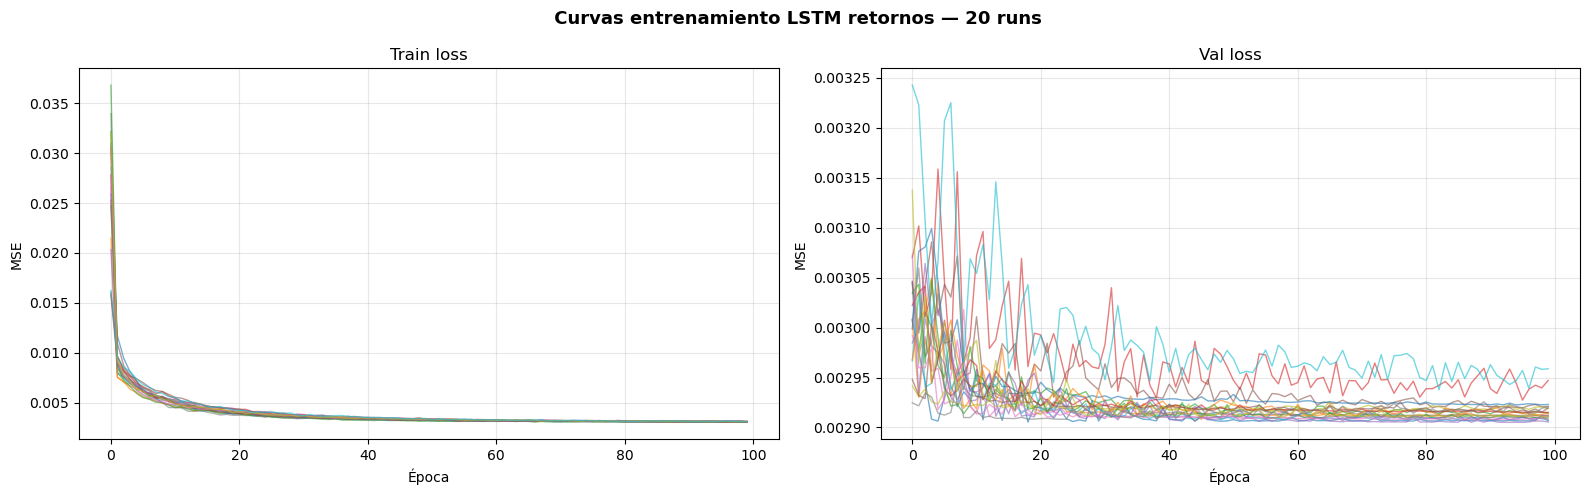

In [ ]:
# Curvas de pérdida para retornos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for h in hist_ret_lista:
    axes[0].plot(h["loss"],     alpha=0.6, linewidth=1)
    axes[1].plot(h["val_loss"], alpha=0.6, linewidth=1)
axes[0].set_title("Train loss"); axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE"); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Val loss");   axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE"); axes[1].grid(True, alpha=0.3)
plt.suptitle(f" Curvas entrenamiento LSTM retornos — {N_RUNS} runs",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

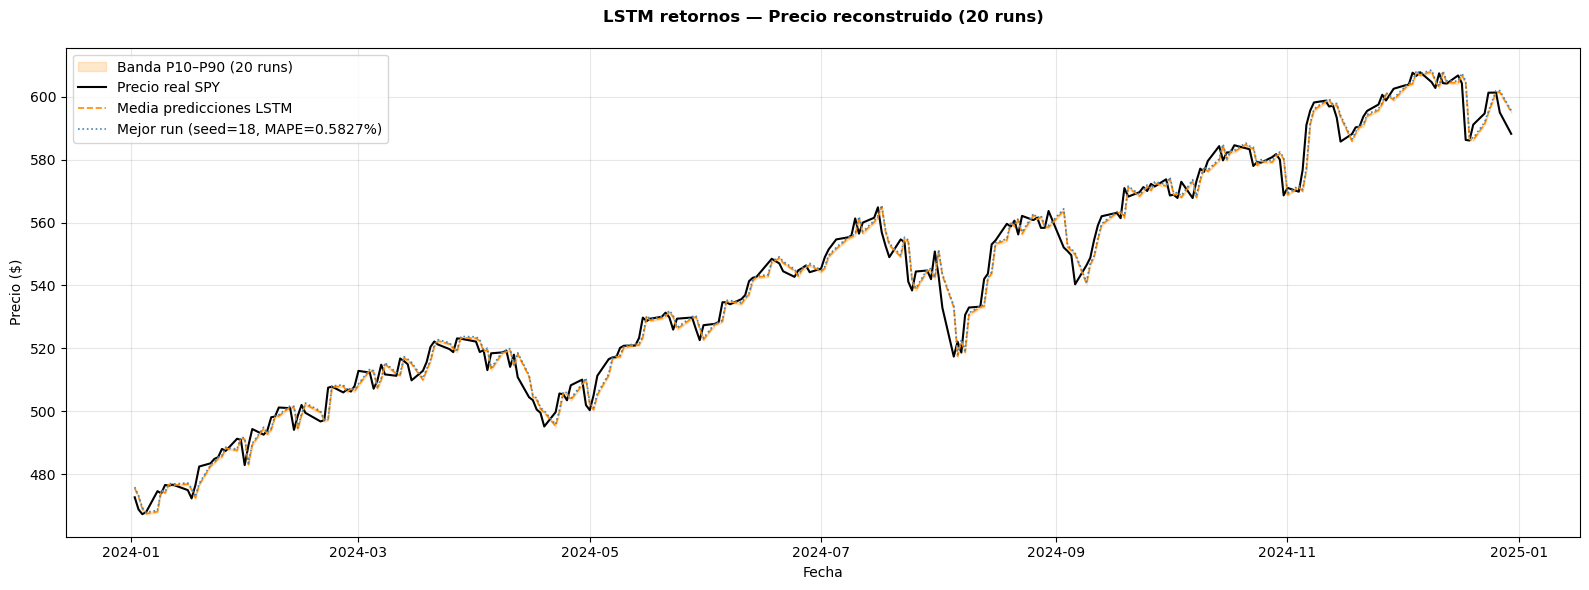

In [26]:
# Precio reconstruido — mejor run retornos
todas_pred_ret_arr = np.array(pred_ret_lista)
precio_q10_ret = precio_prev_arr * (1 + np.percentile(todas_pred_ret_arr, 10, axis=0).ravel() / 100)
precio_q90_ret = precio_prev_arr * (1 + np.percentile(todas_pred_ret_arr, 90, axis=0).ravel() / 100)
precio_media_ret = precio_prev_arr * (1 + todas_pred_ret_arr.mean(axis=0).ravel() / 100)
mejor_precio_ret = precio_prev_arr * (1 + mejor_pred_ret_arr / 100)

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(fechas_test, precio_q10_ret, precio_q90_ret,
                alpha=0.2, color="darkorange",
                label=f"Banda P10–P90 ({N_RUNS} runs)")
ax.plot(fechas_test, precio_real_arr,
        color="black", linewidth=1.5, label="Precio real SPY")
ax.plot(fechas_test, precio_media_ret,
        color="darkorange", linewidth=1.2, linestyle="--",
        label="Media predicciones LSTM")
ax.plot(fechas_test, mejor_precio_ret,
        color="steelblue", linewidth=1.2, linestyle=":",
        label=f"Mejor run (seed={mejor_seed_ret}, MAPE={mejor_mape_ret:.4f}%)")
ax.set_title(f"LSTM retornos — Precio reconstruido ({N_RUNS} runs)\n",fontsize=12, fontweight="bold")
ax.set_ylabel("Precio ($)"); ax.set_xlabel("Fecha")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()

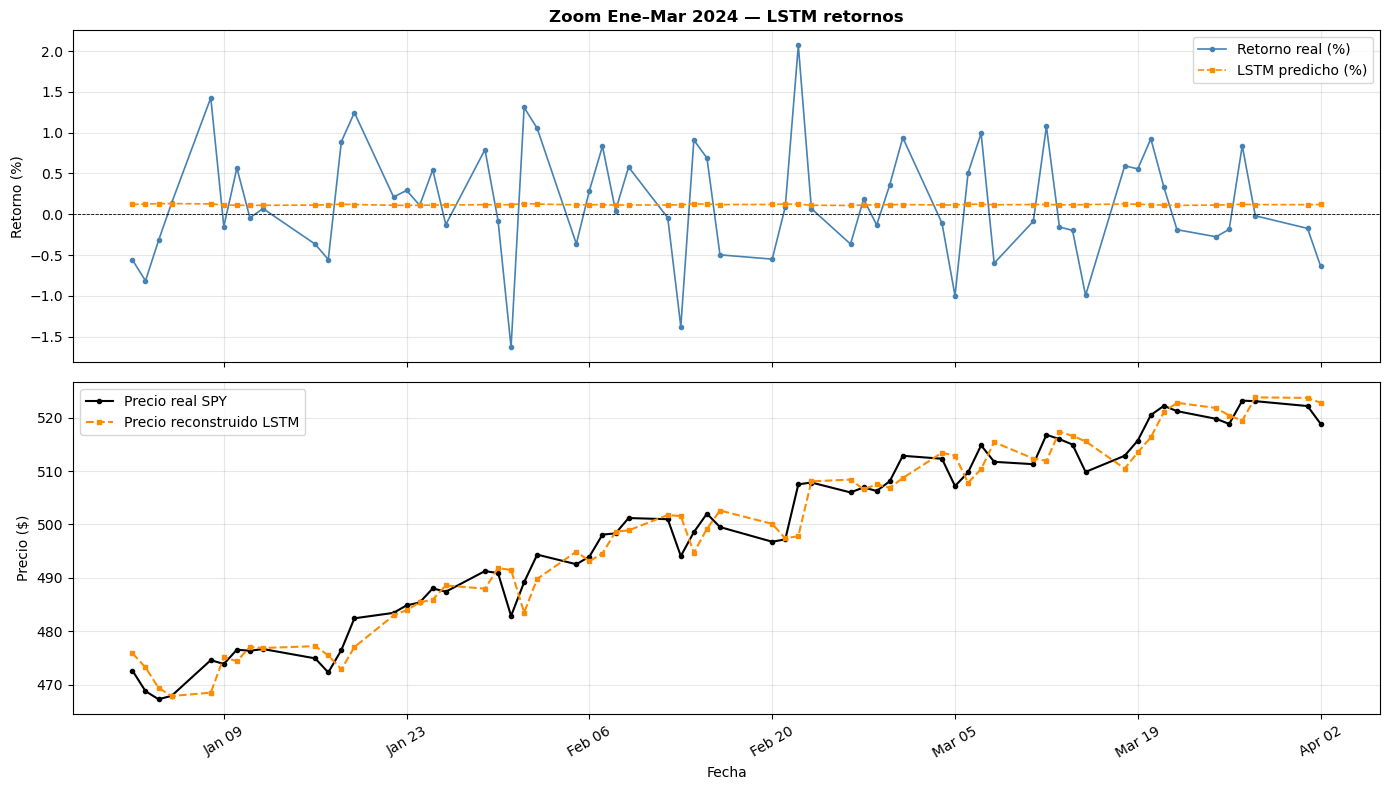

In [27]:
# Zoom retornos 
z1_ini = fechas_test[0]
z1_fin = fechas_test[0] + pd.DateOffset(months=3)
mz1    = (fechas_test >= z1_ini) & (fechas_test <= z1_fin)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(fechas_test[mz1], real_ret_arr[mz1],
             color="steelblue", linewidth=1.2,
             marker="o", markersize=3, label="Retorno real (%)")
axes[0].plot(fechas_test[mz1], mejor_pred_ret_arr[mz1],
             color="darkorange", linewidth=1.2, linestyle="--",
             marker="s", markersize=3, label="LSTM predicho (%)")
axes[0].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[0].set_ylabel("Retorno (%)"); axes[0].legend()
axes[0].set_title("Zoom Ene–Mar 2024 — LSTM retornos", fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[1].plot(fechas_test[mz1], precio_real_arr[mz1],
             color="black", linewidth=1.5,
             marker="o", markersize=3, label="Precio real SPY")
axes[1].plot(fechas_test[mz1], mejor_precio_ret[mz1],
             color="darkorange", linewidth=1.5, linestyle="--",
             marker="s", markersize=3, label="Precio reconstruido LSTM")
axes[1].set_ylabel("Precio ($)"); axes[1].set_xlabel("Fecha")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout(); plt.show()

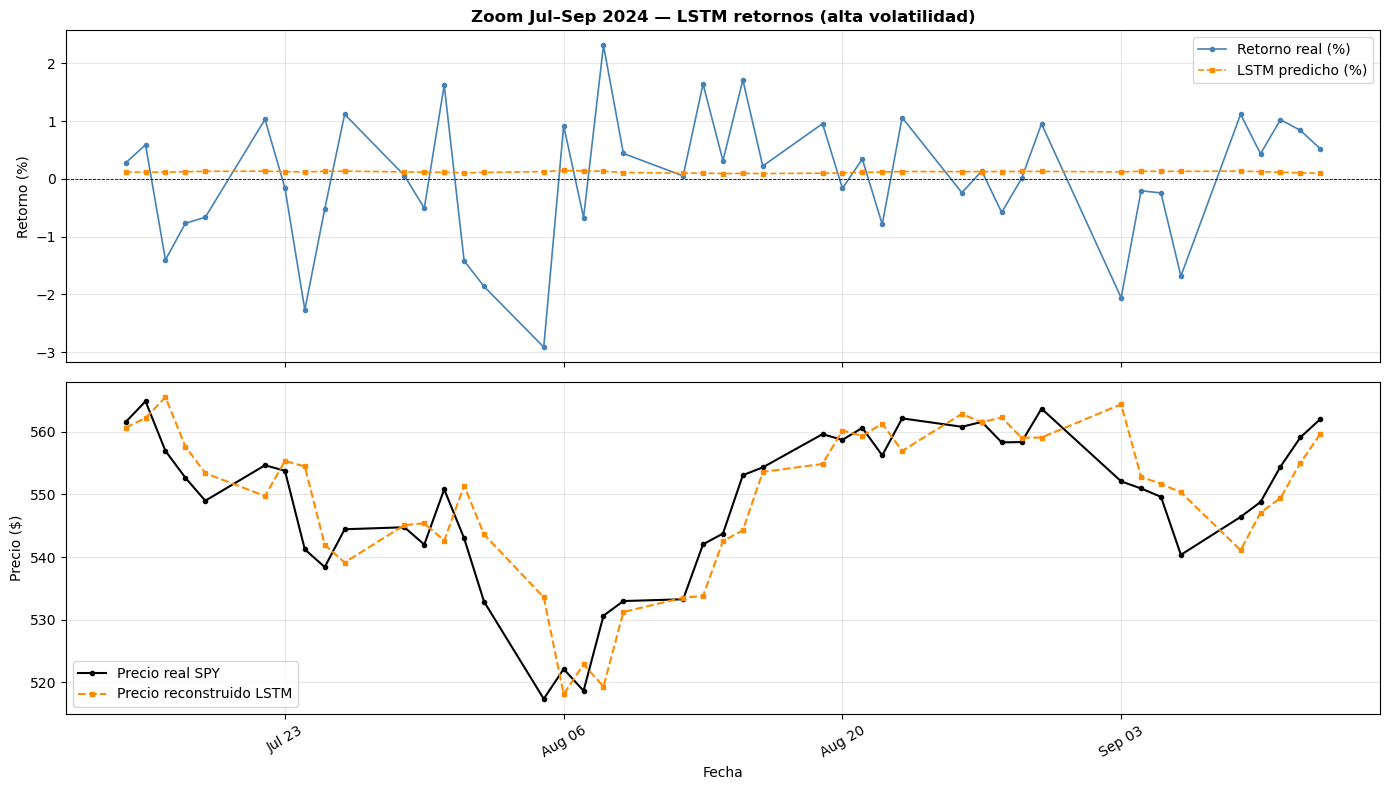

In [28]:
# Zoom retornos - 2
z2_ini = pd.Timestamp("2024-07-15")
z2_fin = pd.Timestamp("2024-09-15")
mz2    = (fechas_test >= z2_ini) & (fechas_test <= z2_fin)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(fechas_test[mz2], real_ret_arr[mz2],
             color="steelblue", linewidth=1.2,
             marker="o", markersize=3, label="Retorno real (%)")
axes[0].plot(fechas_test[mz2], mejor_pred_ret_arr[mz2],
             color="darkorange", linewidth=1.2, linestyle="--",
             marker="s", markersize=3, label="LSTM predicho (%)")
axes[0].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[0].set_ylabel("Retorno (%)"); axes[0].legend()
axes[0].set_title("Zoom Jul–Sep 2024 — LSTM retornos (alta volatilidad)",
                  fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[1].plot(fechas_test[mz2], precio_real_arr[mz2],
             color="black", linewidth=1.5,
             marker="o", markersize=3, label="Precio real SPY")
axes[1].plot(fechas_test[mz2], mejor_precio_ret[mz2],
             color="darkorange", linewidth=1.5, linestyle="--",
             marker="s", markersize=3, label="Precio reconstruido LSTM")
axes[1].set_ylabel("Precio ($)"); axes[1].set_xlabel("Fecha")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout(); plt.show()

## Retornos al cuadrado

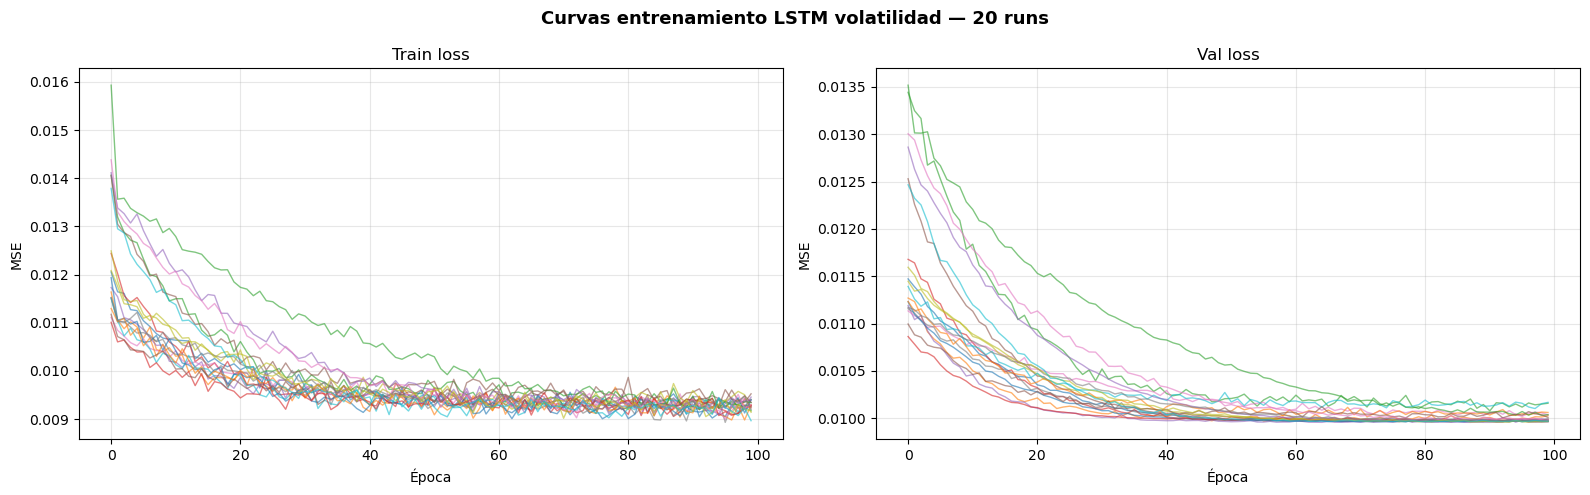

In [29]:
# Curvas de pérdida — LSTM volatilidad
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for h in hist_vol_lista:
    axes[0].plot(h["loss"],     alpha=0.6, linewidth=1)
    axes[1].plot(h["val_loss"], alpha=0.6, linewidth=1)
axes[0].set_title("Train loss"); axes[0].set_xlabel("Época")
axes[0].set_ylabel("MSE"); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Val loss");   axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE"); axes[1].grid(True, alpha=0.3)
plt.suptitle(f"Curvas entrenamiento LSTM volatilidad — {N_RUNS} runs",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [30]:
# Precálculo arrays volatilidad 
todas_pred_vol_arr = np.array(pred_vol_lista)
pred_q10_vol       = np.percentile(todas_pred_vol_arr, 10, axis=0).ravel()
pred_q90_vol       = np.percentile(todas_pred_vol_arr, 90, axis=0).ravel()
pred_med_vol       = todas_pred_vol_arr.mean(axis=0).ravel()
mejor_pred_vol_arr = np.array(mejor_pred_vol).ravel()

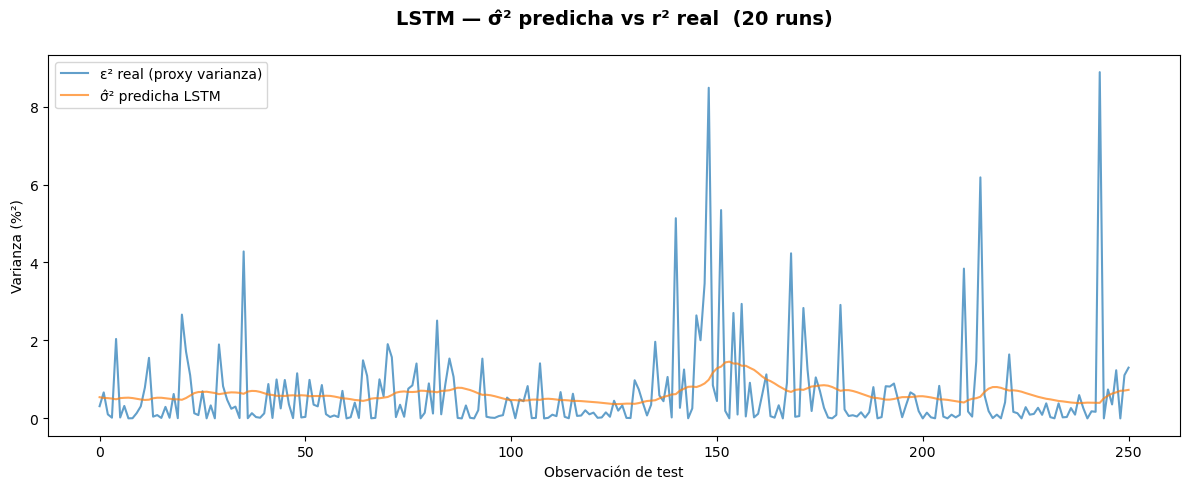

In [31]:
# Gráfico σ̂² predicha vs ε² real
plt.figure(figsize=(12, 5))
plt.plot(r2_real_arr,        label="ε² real (proxy varianza)",    alpha=0.7)
plt.plot(mejor_pred_vol_arr,   label="σ̂² predicha LSTM",     alpha=0.7)
plt.title(f"LSTM — σ̂² predicha vs r² real  ({N_RUNS} runs)\n", fontsize=14, fontweight="bold")
plt.xlabel("Observación de test"); plt.ylabel("Varianza (%²)")
plt.legend(); plt.tight_layout()
plt.show()

## IC

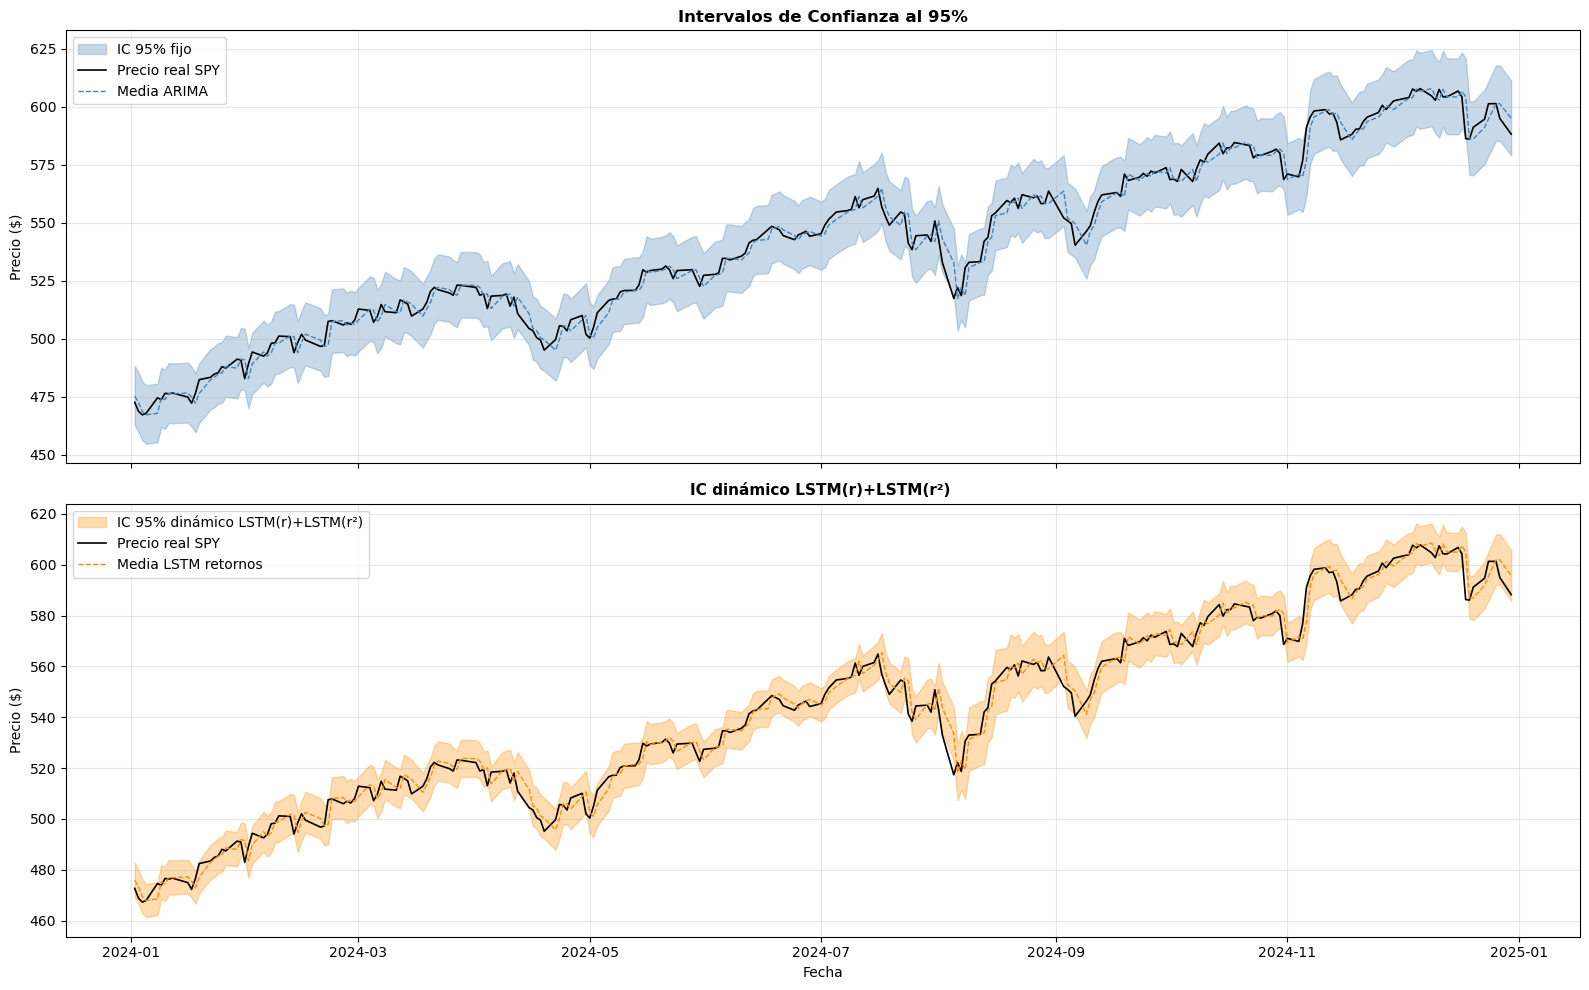

In [32]:
# IC con dos paneles: Fijo / LSTM + LSTM

pred_log_lstm_arr = np.log(precio_prev_arr * (1 + mejor_pred_ret_arr / 100))
precios_pred_lstm = np.exp(pred_log_lstm_arr)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel 1 — IC fijo
axes[0].fill_between(fechas_test, li_fijo, ls_fijo,
                     alpha=0.3, color="steelblue", label="IC 95% fijo")
axes[0].plot(fechas_test, precio_real_arr,
             color="black", linewidth=1.2, label="Precio real SPY")
axes[0].plot(fechas_test, precios_pred,
             color="steelblue", linewidth=1.0, linestyle="--",
             label="Media ARIMA")
axes[0].set_ylabel("Precio ($)")
axes[0].set_title(f"Intervalos de Confianza al 95%", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Panel 2 — IC LSTM+LSTM
axes[1].fill_between(fechas_test, li_lstm, ls_lstm,
                     alpha=0.3, color="darkorange",
                     label="IC 95% dinámico LSTM(r)+LSTM(r²)")
axes[1].plot(fechas_test, precio_real_arr,
             color="black", linewidth=1.2, label="Precio real SPY")
axes[1].plot(fechas_test, precios_pred_lstm,
             color="darkorange", linewidth=1.0, linestyle="--",
             label="Media LSTM retornos")
axes[1].set_ylabel("Precio ($)"); axes[1].set_xlabel("Fecha")
axes[1].set_title(f"IC dinámico LSTM(r)+LSTM(r²) ", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout(); plt.show()


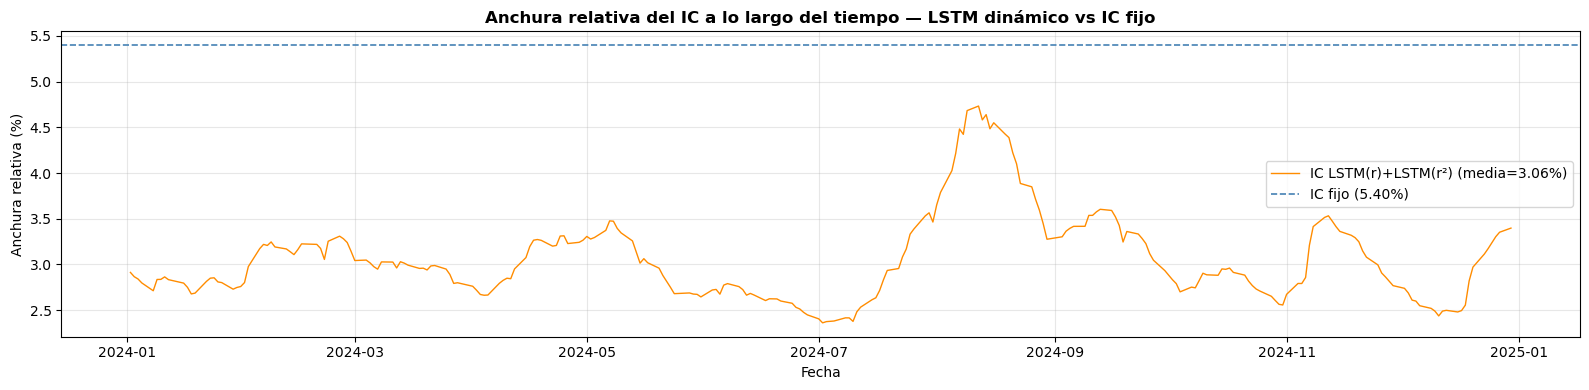

In [33]:
# G11. Anchura IC a lo largo del tiempo — fijo vs LSTM
anchura_fijo_ts = ((ls_fijo - li_fijo) / precio_real_arr) * 100
anchura_lstm_ts = ((ls_lstm - li_lstm) / precio_real_arr) * 100

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(fechas_test, anchura_lstm_ts,
        color="darkorange", linewidth=1.0,
        label=f"IC LSTM(r)+LSTM(r²) (media={anc_lstm:.2f}%)")
ax.axhline(anc_fijo, color="steelblue", linestyle="--",
           linewidth=1.2, label=f"IC fijo ({anc_fijo:.2f}%)")
ax.set_ylabel("Anchura relativa (%)"); ax.set_xlabel("Fecha")
ax.set_title("Anchura relativa del IC a lo largo del tiempo — "
             "LSTM dinámico vs IC fijo",
             fontweight="bold")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()

# Resumen final

In [34]:

print("\n" + "="*65)
print("  RESUMEN GLOBAL")
print("="*65)
print(f"\n  [A] PREDICCIÓN EN MEDIA")
print(f"  {'Modelo':<30} {'MAE':>8} {'RMSE':>8} {'MAPE':>9}")
print(f"  {'─'*58}")
print(f"  {'LSTM retornos (media)':.<30} {media_ret['MAE']:>8.4f} "
      f"{media_ret['RMSE']:>8.4f} {media_ret['MAPE']:>8.4f}%")
print(f"  {'ARIMA(0,1,0)':.<30} {ARIMA_REF['MAE']:>8.4f} "
      f"{ARIMA_REF['RMSE']:>8.4f} {ARIMA_REF['MAPE']:>8.4f}%")

print(f"\n  [B] PREDICCIÓN DE VOLATILIDAD")
print(f"  {'Modelo':<30} {'MSE':>12} {'QLIKE':>10}")
print(f"  {'─'*55}")

print(f"  {'LSTM r² (media)':.<30} {media_vol['MSE']:>12.6f} "
      f"{media_vol['QLIKE']:>10.6f}")
print(f"  {'GARCH(1,1)-t':.<30} {GARCH_REF['MSE']:>12.6f} "
      f"{GARCH_REF['QLIKE']:>10.6f}")

print(f"\n  [C] INTERVALOS DE CONFIANZA AL 95%")
print(f"  {'Modelo IC':<30} {'Cobertura':>12} {'Anchura':>10}")
print(f"  {'─'*55}")
print(f"  {'IC fijo':.<30} {cob_fijo:>11.1f}% {anc_fijo:>9.2f}%")
print(f"  {'IC ARIMA+GARCH':.<30} {IC_GARCH['Cobertura']:>11.1f}% "
      f"{IC_GARCH['Anchura']:>9.2f}%")
print(f"  {'IC LSTM(r)+LSTM(r²)':.<30} {cob_lstm:>11.1f}% {anc_lstm:>9.2f}%")
print("="*65)


  RESUMEN GLOBAL

  [A] PREDICCIÓN EN MEDIA
  Modelo                              MAE     RMSE      MAPE
  ──────────────────────────────────────────────────────────
  LSTM retornos (media).........   3.1778   4.3200   0.5888%
  ARIMA(0,1,0)..................   3.1912   4.3229   0.5912%

  [B] PREDICCIÓN DE VOLATILIDAD
  Modelo                                  MSE      QLIKE
  ───────────────────────────────────────────────────────
  LSTM r² (media)...............     1.366317   0.573546
  GARCH(1,1)-t..................     1.409003   0.559411

  [C] INTERVALOS DE CONFIANZA AL 95%
  Modelo IC                         Cobertura    Anchura
  ───────────────────────────────────────────────────────
  IC fijo.......................        99.2%      5.40%
  IC ARIMA+GARCH................        97.2%      4.00%
  IC LSTM(r)+LSTM(r²)...........        94.4%      3.06%
